# Análisis de bebidas energizantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

## Contenido
1. [Planeamiento del problema](#1.-planeamiento-del-problema)
2. [Exploración del set de datos](#2.-exploración-del-set-de-datos)
3. [Limpieza del set de datos](#3.-limpieza-del-set-de-datos)
4. [Análisis exploratorio de datos](#4.-análisis-exploratorio-de-datos)
5. [Generación de gráficos](#5.-generación-de-gráficos)
6. [Reporte final y recomendaciones](#6.-reporte-final-y-recomendaciones)

## 1. Planeamiento del problema
MegaBoost es una marca de bebidas energizantes de Inglaterra y desea ingresar al mercado italiano. Hace algunos meses lanzaron su bebida en 10 ciudades de Italia.

El equipo de marketing está a cargo de incrementar el posicionamiento de la marca y la participación en el mercado, además de apoyar el desarrollo del producto. Para esto aplicaron una encuesta a 10.000 personas en esas 10 ciudades.

### 1.1. Tarea a realizar

Su labor es extraer los siguientes *insights* a partir de los datos:

- **Demográficos:**
    - ¿Quiénes prefieren esta bebida energética?
    - ¿Qué rangos de edad tienden a preferir la bebida?
 
- **Análisis de la competencia:**
    - ¿Quiénes son los actuales líderes del mercado?

- **Canales de mercadeo y conocimiento de la marca:**
    - ¿Cuál es el canal de mercadeo más efectivo?
    
- **Penetración de la marca:**
    - ¿Qué piensa la gente de nuestra marca?
    - ¿En qué ciudades debemos reforzar este posicionamiento?
    - ¿Por qué los consumidores prefieren otras marcas y no las nuestras?

- **Preferencias del consumidor:**
    - ¿Cuáles son los ingredientes preferidos?
    - ¿Qué tipo de paquetes son los preferidos?

- **Comportamientos de compra:**
    - ¿Dónde prefieren las personas comprar bebidas energizantes?
    - ¿Cuáles son las situaciones típicas de consumo de bebibas energéticas?
    - ¿Qué factores influyen más en las decisiones de compra de las personas?

- **Desarrollo de producto:**
    - ¿Qué área deberíamos priorizar para el desarrollo y mejora del producto?

## 2. Exploración del set de datos

In [2]:
#Leer el dataset
df = pd.read_csv(r".\data\dataset_bebida_energizante.csv")
df

,ID_encuestado,Edad,Género,ID_Ciudad,ID_respuesta,Frec_consumo,Momento_consumo,Motivo_consumo,Conocía_marca,Percepción_marca,...,Preocupaciones_salud,Interés_en_natural_o_organico,Canales_marketing,Preferencia_empaque,Empaque_ed_limitada,Rango_precios,Lugar_compra,Situaciones_típicas_consumo,Ciudad,Cat_Ciudad
0,120031,15-18,Mujer,CD117,103001,2-3 veces por semana,Durante el trabajo/estudio,Mayor concentración,Sí,Neutral,...,No,Sí,Publicidad en TV,Latas compactas y portables,Sí,1-2.49,Supermercados,Al estudiar/trabajar hasta tarde,Verona,Cat. 2
1,120032,19-30,Hombre,CD118,103002,2-3 veces al mes,A lo largo del día,Aumentar rendimiento,No,Neutral,...,Sí,Indiferente,Medios impresos,Latas compactas y portables,No,1-2.49,Supermercados,Al hacer deporte,Génova,Cat. 2
2,120033,15-18,Hombre,CD116,103003,Ocasional,Antes de hacer ejercicio,Mayor concentración,No,Neutral,...,No,Sí,Publicidad online,Botella con diseño innnovador,Indiferente,2.49-4,Supermercados,Al estudiar/trabajar hasta tarde,Venecia,Cat. 1
3,120034,31-45,Mujer,CD113,103004,2-3 veces por semana,Durante el trabajo/estudio,Aumentar rendimiento,No,Positiva,...,No,Sí,Publicidad online,Latas compactas y portables,No,Más de 4,Supermercados,Al hacer deporte,Turín,Cat. 1
4,120035,19-30,Mujer,CD120,103005,A diario,Durante el trabajo/estudio,Mayor concentración,Sí,Neutral,...,Sí,Sí,Publicidad online,Latas compactas y portables,Sí,2.49-4,Tiendas online,Al estudiar/trabajar hasta tarde,Siena,Cat. 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,130026,31-45,Hombre,CD112,112996,A diario,Antes de hacer ejercicio,Mejorar desempeño deportivo,Sí,Neutral,...,No,No,Medios impresos,Latas compactas y portables,Sí,2.49-4,Supermercados,Al estudiar/trabajar hasta tarde,Roma,Cat. 1
9996,130027,15-18,Hombre,CD113,112997,A diario,Durante el trabajo/estudio,Combatir fatiga,No,Positiva,...,No,No,Publicidad en TV,Otro,Sí,1-2.49,Tiendas online,Social outings/parties,Turín,Cat. 1
9997,130028,31-45,Hombre,CD114,112998,A diario,Antes de hacer ejercicio,Mayor concentración,Sí,Positiva,...,Sí,No,Vallas publicitarias,Latas compactas y portables,No,2.49-4,Otros,Al hacer deporte,Florencia,Cat. 1
9998,130029,19-30,Hombre,CD113,112999,2-3 veces por semana,Durante el trabajo/estudio,Mayor concentración,No,Positiva,...,Sí,Sí,Publicidad online,Latas compactas y portables,Indiferente,1-2.49,Supermercados,Al estudiar/trabajar hasta tarde,Turín,Cat. 1


### 2.1. Entender el tamaño del set datos y sus tipos

In [3]:
#Vemos el tamaño del dataset
df.shape

(10000, 28)

In [4]:
#Vemos los tipos de datos del df
df.dtypes

ID_encuestado                    int64
Edad                               str
Género                             str
ID_Ciudad                          str
ID_respuesta                     int64
Frec_consumo                       str
Momento_consumo                    str
Motivo_consumo                     str
Conocía_marca                      str
Percepción_marca                   str
Percepción_general                 str
Había_probado                      str
Experiencia_sabor                int64
Motivos_no_probarla                str
Marcas_que_consume                 str
Motivos_escoger_marca              str
Mejoras_sugeridas                  str
Ingredientes_esperados             str
Preocupaciones_salud               str
Interés_en_natural_o_organico      str
Canales_marketing                  str
Preferencia_empaque                str
Empaque_ed_limitada                str
Rango_precios                      str
Lugar_compra                       str
Situaciones_típicas_consu

In [5]:
#Observamos que la columna `Experiencia_sabor` es en realidad una variable categorica (de 1 a 5 siendo 5 el valor mas favorable)
#Convertimos la variable a un string para tenerlo en cuenta como una varaible categorica
#A partir de aca voy a trabajar sobre df_copy 
df_copy = df.copy()
df_copy["Experiencia_sabor"] = df_copy["Experiencia_sabor"].astype("str")
df_copy.dtypes

ID_encuestado                    int64
Edad                               str
Género                             str
ID_Ciudad                          str
ID_respuesta                     int64
Frec_consumo                       str
Momento_consumo                    str
Motivo_consumo                     str
Conocía_marca                      str
Percepción_marca                   str
Percepción_general                 str
Había_probado                      str
Experiencia_sabor                  str
Motivos_no_probarla                str
Marcas_que_consume                 str
Motivos_escoger_marca              str
Mejoras_sugeridas                  str
Ingredientes_esperados             str
Preocupaciones_salud               str
Interés_en_natural_o_organico      str
Canales_marketing                  str
Preferencia_empaque                str
Empaque_ed_limitada                str
Rango_precios                      str
Lugar_compra                       str
Situaciones_típicas_consu

In [6]:
#ver el rango de valores de las variables numericas
df_copy.describe()

,ID_encuestado,ID_respuesta
count,10000.00000,10000.00000
mean,125030.50000,108000.50000
std,2886.89568,2886.89568
min,120031.00000,103001.00000
25%,122530.75000,105500.75000
50%,125030.50000,108000.50000
75%,127530.25000,110500.25000
max,130030.00000,113000.00000


#### **Observaciones**
> - las columnas ID_encuestado e ID_respuesta no poseen información relevante para el problema que estamos intentando resolver
> - pueden ser eliminadas posteriormente en la fase de limpieza

### 2.2. Examinar y entender las variables categoricas 

In [7]:
#Seleccionamos todas las columnas que no son numericas
#df_copy.select_dtypes(exclude="number").columns
#Imprimimos las variables para analizarlas
for cat in df_copy.select_dtypes(exclude="number").columns:
    print("-"*30)
    print(f"Categoria: {df_copy[cat].value_counts()}")
    print("-"*30)
    print(" ")

------------------------------
Categoria: Edad
19-30    5513
31-45    2372
15-18    1487
46-65     426
65+       190
Name: count, dtype: int64
------------------------------
 
------------------------------
Categoria: Género
Hombre        6038
Mujer         3455
No binario     507
Name: count, dtype: int64
------------------------------
 
------------------------------
Categoria: ID_Ciudad
CD113    2828
CD116    1833
CD112    1510
CD114     937
CD118     906
CD115     566
CD117     456
CD111     429
CD119     360
CD120     175
Name: count, dtype: int64
------------------------------
 
------------------------------
Categoria: Frec_consumo
2-3 veces por semana    3489
Ocasional               1936
2-3 veces al mes        1609
1 vez por semana        1609
A diario                1345
Name: count, dtype: int64
------------------------------
 
------------------------------
Categoria: Momento_consumo
Durante el trabajo/estudio                        3409
Antes de hacer ejercicio            

#### **Observaciones**
> - La mayoria de los encuestados son hombres
> - La columnas ID_ciudad no aportan valor relevante para el problema a resolver
> - la mayoria de las edades estan entre 19 a 30 años

### 2.3. Verificar si hay datos faltantes

In [8]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   ID_encuestado                  10000 non-null  int64
 1   Edad                           9988 non-null   str  
 2   Género                         10000 non-null  str  
 3   ID_Ciudad                      10000 non-null  str  
 4   ID_respuesta                   10000 non-null  int64
 5   Frec_consumo                   9988 non-null   str  
 6   Momento_consumo                10000 non-null  str  
 7   Motivo_consumo                 9988 non-null   str  
 8   Conocía_marca                  10000 non-null  str  
 9   Percepción_marca               10000 non-null  str  
 10  Percepción_general             10000 non-null  str  
 11  Había_probado                  9988 non-null   str  
 12  Experiencia_sabor              10000 non-null  str  
 13  Motivos_no_probarla         

In [9]:
#Sumamos el total de columnas con datos faltantes
df.isna().sum()

ID_encuestado                     0
Edad                             12
Género                            0
ID_Ciudad                         0
ID_respuesta                      0
Frec_consumo                     12
Momento_consumo                   0
Motivo_consumo                   12
Conocía_marca                     0
Percepción_marca                  0
Percepción_general                0
Había_probado                    12
Experiencia_sabor                 0
Motivos_no_probarla               0
Marcas_que_consume                0
Motivos_escoger_marca             0
Mejoras_sugeridas                 0
Ingredientes_esperados            0
Preocupaciones_salud              0
Interés_en_natural_o_organico     0
Canales_marketing                 0
Preferencia_empaque               0
Empaque_ed_limitada               0
Rango_precios                     0
Lugar_compra                      0
Situaciones_típicas_consumo       0
Ciudad                            0
Cat_Ciudad                  

#### **Observaciones**
> - Hay 4 columnas con 12 datos faltantes cada una `Edad`, `Frec_consumo`, `Motivo_consumo`, `Habia_probado`
> - Al tratarse de columnas revelantes para nuestro analisis NO las eliminaremos


Luego de echar un vistazo a los datos y entender un poco las variables toca la fase de limpieza

## 3. Limpieza del set de datos

### 3.1. Eliminar tildes y aplicar snake_case a las columnas 
Esto es decisión personal para que no haya ningun problema con los datos luego

In [10]:
# Mapeo de vocales con tilde o diéresis a sus equivalentes sin acento
traduccion = str.maketrans('áéíóúÁÉÍÓÚüÜ', 'aeiouaeiouuu')

print("Columnas Antes:")
print(df_copy.columns)

print("-"*50)
# Aplicar la limpieza a las columnas: reemplazar caracteres y convertir a minúsculas
df_copy.columns = [col.translate(traduccion).lower() for col in df_copy.columns]
print("Columnas Despues:")
print(df_copy.columns)

Columnas Antes:
Index(['ID_encuestado', 'Edad', 'Género', 'ID_Ciudad', 'ID_respuesta',
       'Frec_consumo', 'Momento_consumo', 'Motivo_consumo', 'Conocía_marca',
       'Percepción_marca', 'Percepción_general', 'Había_probado',
       'Experiencia_sabor', 'Motivos_no_probarla', 'Marcas_que_consume',
       'Motivos_escoger_marca', 'Mejoras_sugeridas', 'Ingredientes_esperados',
       'Preocupaciones_salud', 'Interés_en_natural_o_organico',
       'Canales_marketing', 'Preferencia_empaque', 'Empaque_ed_limitada',
       'Rango_precios', 'Lugar_compra', 'Situaciones_típicas_consumo',
       'Ciudad', 'Cat_Ciudad'],
      dtype='str')
--------------------------------------------------
Columnas Despues:
Index(['id_encuestado', 'edad', 'genero', 'id_ciudad', 'id_respuesta',
       'frec_consumo', 'momento_consumo', 'motivo_consumo', 'conocia_marca',
       'percepcion_marca', 'percepcion_general', 'habia_probado',
       'experiencia_sabor', 'motivos_no_probarla', 'marcas_que_consume',
  

### 3.2. Eliminar columnas irrelevantes
Eliminaremos las columnas **id_encuestado**, **id_respuesta** ,**id_ciudad**

In [11]:
df_copy.drop(columns=["id_encuestado", "id_respuesta", "id_ciudad"], inplace=True)

In [12]:
#Nos hemos quedado con 25 columnas
df_copy.shape

(10000, 25)

### 3.3. Organizar las columnas
Organizar por categorías relevantes para que tengan cierta coherencia y facilitar el análisis exploratorio luego

**Demograficos**
- edad
- genero
- ciudad
- cat_ciudad
  
**Consumo**
- frec_consumo
- momento_consumo
- motivo_consumo
- situaciones_tipicas_consumo

**Conocimiento Marca**
- conocia_marca
- percepcion_marca
- percepción_general

**Competencia**
- marcas_que_consume
- motivos_escoger_marca
- mejoras_sugeridas

**Experiencia Producto**
- Habia_probado
- Experiencia_sabor
- Motivos_no_probarla

**Ingredientes & Salud**
- ingredientes_esperados
- preocupaciones_salud
- interes_en_natural_o_organico

**Mercadeo**
- canales_marketing
- preferencia_empaque
- empaque_ed_limitada
- lugar_compra
- rango_precios

In [13]:
demograficos = ["edad", "genero", "ciudad", "cat_ciudad"]
habitos_consumo = ["frec_consumo", "momento_consumo", "motivo_consumo", "situaciones_tipicas_consumo"]
marca = ["conocia_marca", "percepcion_marca", "percepcion_general"]
competencia = ["marcas_que_consume", "motivos_escoger_marca", "mejoras_sugeridas"]
experiencia_prod = ["habia_probado", "experiencia_sabor", "motivos_no_probarla"]
salud_ing = ["ingredientes_esperados", "preocupaciones_salud", "interes_en_natural_o_organico"]
mercadeo = ["canales_marketing", "preferencia_empaque", "empaque_ed_limitada", "lugar_compra", "rango_precios"]

In [14]:
#Ahora reorganizamos las columnas por importancia del problema a resolver
col_order = demograficos + marca + experiencia_prod + competencia + mercadeo + habitos_consumo + salud_ing

In [15]:
pd.set_option('display.max_columns', 200)
df_copy = df_copy[col_order]
df_copy

,edad,genero,ciudad,cat_ciudad,conocia_marca,percepcion_marca,percepcion_general,habia_probado,experiencia_sabor,motivos_no_probarla,marcas_que_consume,motivos_escoger_marca,mejoras_sugeridas,canales_marketing,preferencia_empaque,empaque_ed_limitada,lugar_compra,rango_precios,frec_consumo,momento_consumo,motivo_consumo,situaciones_tipicas_consumo,ingredientes_esperados,preocupaciones_salud,interes_en_natural_o_organico
0,15-18,Mujer,Verona,Cat. 2,Sí,Neutral,No estoy segur@,No,5,No conozco la marca,Red Bull,Fácil de encontrar,Reducir contenido de azúcar,Publicidad en TV,Latas compactas y portables,Sí,Supermercados,1-2.49,2-3 veces por semana,Durante el trabajo/estudio,Mayor concentración,Al estudiar/trabajar hasta tarde,Guaraná,No,Sí
1,19-30,Hombre,Génova,Cat. 2,No,Neutral,No estoy segur@,No,5,No me interesan las bebidas energéticas,Pepsi,Fácil de encontrar,Más ingredientes naturales,Medios impresos,Latas compactas y portables,No,Supermercados,1-2.49,2-3 veces al mes,A lo largo del día,Aumentar rendimiento,Al hacer deporte,Cafeína,Sí,Indiferente
2,15-18,Hombre,Venecia,Cat. 1,No,Neutral,No estoy segur@,No,2,No disponible en la ciudad,Pepsi,Fácil de encontrar,Más ingredientes naturales,Publicidad online,Botella con diseño innnovador,Indiferente,Supermercados,2.49-4,Ocasional,Antes de hacer ejercicio,Mayor concentración,Al estudiar/trabajar hasta tarde,Cafeína,No,Sí
3,31-45,Mujer,Turín,Cat. 1,No,Positiva,Dañina,Sí,5,Otro,Pepsi,Otro,Otra,Publicidad online,Latas compactas y portables,No,Supermercados,Más de 4,2-3 veces por semana,Durante el trabajo/estudio,Aumentar rendimiento,Al hacer deporte,Cafeína,No,Sí
4,19-30,Mujer,Siena,Cat. 2,Sí,Neutral,Efectiva,Sí,5,Otro,HyperFuel,Otro,Más ingredientes naturales,Publicidad online,Latas compactas y portables,Sí,Tiendas online,2.49-4,A diario,Durante el trabajo/estudio,Mayor concentración,Al estudiar/trabajar hasta tarde,Cafeína,Sí,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,31-45,Hombre,Roma,Cat. 1,Sí,Neutral,No estoy segur@,No,4,Preocupaciones de salud,Coca Cola,Reputación de la marca,Otra,Medios impresos,Latas compactas y portables,Sí,Supermercados,2.49-4,A diario,Antes de hacer ejercicio,Mejorar desempeño deportivo,Al estudiar/trabajar hasta tarde,Cafeína,No,No
9996,15-18,Hombre,Turín,Cat. 1,No,Positiva,Saludable,Sí,2,No disponible en la ciudad,Monster,Efectividad,Más ingredientes naturales,Publicidad en TV,Otro,Sí,Tiendas online,1-2.49,A diario,Durante el trabajo/estudio,Combatir fatiga,Social outings/parties,Cafeína,No,No
9997,31-45,Hombre,Florencia,Cat. 1,Sí,Positiva,Efectiva,No,2,Otro,Red Bull,Fácil de encontrar,Otra,Vallas publicitarias,Latas compactas y portables,No,Otros,2.49-4,A diario,Antes de hacer ejercicio,Mayor concentración,Al hacer deporte,Cafeína,Sí,No
9998,19-30,Hombre,Turín,Cat. 1,No,Positiva,Saludable,No,4,No conozco la marca,Red Bull,El sabor,Otra,Publicidad online,Latas compactas y portables,Indiferente,Supermercados,1-2.49,2-3 veces por semana,Durante el trabajo/estudio,Mayor concentración,Al estudiar/trabajar hasta tarde,Azúcar,Sí,Sí


### 3.4. Manejo de datos faltantes
En nuestro caso todos los datos son categóricos. En este caso usualmente tenemos estas alternativas:
1. **Eliminar la fila completa:** Si los datos faltantes son pocos en relación a la cantidad de datos puede ser adecuado
2. **Reemplazar los datos faltantes con el valor más frecuente:** Si los datos son pocos o por algun motivo o se deben eliminar, pero esto puede generar un sesgo en los datos
3. **Desarrollar un modelo que prediga los datos faltantes:** Un modelo de ML que con base a los datos completos genere datos para las columnas faltantes
4. **Eliminar la columna:** Se puede llevar a cabo si la columna no es de interes

En este caso por ser tan pocos las filas faltantes lo que haremos sera optar por eliminar las filas con **dropna**

In [16]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   edad                           9988 non-null   str  
 1   genero                         10000 non-null  str  
 2   ciudad                         10000 non-null  str  
 3   cat_ciudad                     10000 non-null  str  
 4   conocia_marca                  10000 non-null  str  
 5   percepcion_marca               10000 non-null  str  
 6   percepcion_general             10000 non-null  str  
 7   habia_probado                  9988 non-null   str  
 8   experiencia_sabor              10000 non-null  str  
 9   motivos_no_probarla            10000 non-null  str  
 10  marcas_que_consume             10000 non-null  str  
 11  motivos_escoger_marca          10000 non-null  str  
 12  mejoras_sugeridas              10000 non-null  str  
 13  canales_marketing           

In [17]:
df_copy = df_copy.dropna()
df_copy.info()

<class 'pandas.DataFrame'>
Index: 9988 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   edad                           9988 non-null   str  
 1   genero                         9988 non-null   str  
 2   ciudad                         9988 non-null   str  
 3   cat_ciudad                     9988 non-null   str  
 4   conocia_marca                  9988 non-null   str  
 5   percepcion_marca               9988 non-null   str  
 6   percepcion_general             9988 non-null   str  
 7   habia_probado                  9988 non-null   str  
 8   experiencia_sabor              9988 non-null   str  
 9   motivos_no_probarla            9988 non-null   str  
 10  marcas_que_consume             9988 non-null   str  
 11  motivos_escoger_marca          9988 non-null   str  
 12  mejoras_sugeridas              9988 non-null   str  
 13  canales_marketing              998

#### **Observación**
> - De las 10000 filas ahora todas tienen 9988, es decir se eliminar en total 12 filas del dataset

## 4. Analisis exploratorio de datos
Debemos regresar al planteamiento inicial del problema y a los insights que queremos encontrar

Realizaremos el analisis enfocandonos de manera individual a cada grupo de insights a descubrir

### 4.1.  Analisis demográfico
- ¿Quiénes prefieren esta bebida energética?
- ¿Qué rangos de edad tienden a preferir la bebida?

In [18]:
df_copy[demograficos]

,edad,genero,ciudad,cat_ciudad
0,15-18,Mujer,Verona,Cat. 2
1,19-30,Hombre,Génova,Cat. 2
2,15-18,Hombre,Venecia,Cat. 1
3,31-45,Mujer,Turín,Cat. 1
4,19-30,Mujer,Siena,Cat. 2
...,...,...,...,...
9995,31-45,Hombre,Roma,Cat. 1
9996,15-18,Hombre,Turín,Cat. 1
9997,31-45,Hombre,Florencia,Cat. 1
9998,19-30,Hombre,Turín,Cat. 1


Columnas relevantes para responder a ¿Quiénes prefieren esta bebida energética? podrián ser `edad`, `genero`, `habia_probado`, `experiencia_sabor`, `percepcion_marca`, `marcas_que_consume`
> deberiamos ver la proporción de edades y de generos y luego ver de esa proporción los que la han  probado y en marcas que consume "MegaBoost"

In [19]:
print("-"*40)
print(df_copy["edad"].value_counts(normalize=True).map("{:.2%}".format))
print("-"*40)
print(df_copy["genero"].value_counts(normalize=True).map("{:.2%}".format))
print("-"*40)
print(df_copy["ciudad"].value_counts(normalize=True).map("{:.2%}".format))
print("-"*40)

----------------------------------------
edad
19-30    55.20%
31-45    23.75%
15-18    14.89%
46-65     4.27%
65+       1.90%
Name: proportion, dtype: str
----------------------------------------
genero
Hombre        60.39%
Mujer         34.54%
No binario     5.07%
Name: proportion, dtype: str
----------------------------------------
ciudad
Turín        28.27%
Venecia      18.30%
Roma         15.10%
Florencia     9.38%
Génova        9.07%
Palermo       5.67%
Verona        4.56%
Milán         4.30%
Pisa          3.60%
Siena         1.75%
Name: proportion, dtype: str
----------------------------------------


In [20]:
df_copy["marcas_que_consume"].value_counts(normalize=True).map("{:.2%}".format)

marcas_que_consume
Coca Cola    25.39%
Pepsi        21.12%
Monster      18.53%
Red Bull     10.59%
HyperFuel     9.80%
MegaBoost     9.77%
Otras         4.80%
Name: proportion, dtype: str

> **Observacion**: Vemos que de los 9988 encuestados casi el 10% prefiere nuestra bebida "MegaBoost"

In [21]:
print("-"*40)
print("Distribución de edades:")
print(df_copy.loc[df_copy["marcas_que_consume"] == "MegaBoost",["edad"]].value_counts(normalize=True).map("{:.2%}".format))
print("-"*40)
print(" ")
print("-"*40)
print("Distribución de generos:")
print(df_copy.loc[df_copy["marcas_que_consume"] == "MegaBoost",["genero"]].value_counts(normalize=True).map("{:.2%}".format))
print("-"*40)
print(" ")
print("-"*40)
print("Distribución de ciudades:")
print(df_copy.loc[df_copy["marcas_que_consume"] == "MegaBoost",["ciudad"]].value_counts(normalize=True).map("{:.2%}".format))
print("-"*40)

----------------------------------------
Distribución de edades:
edad 
19-30    55.02%
31-45    24.69%
15-18    13.83%
46-65     3.79%
65+       2.66%
Name: proportion, dtype: str
----------------------------------------
 
----------------------------------------
Distribución de generos:
genero    
Hombre        60.25%
Mujer         35.86%
No binario     3.89%
Name: proportion, dtype: str
----------------------------------------
 
----------------------------------------
Distribución de ciudades:
ciudad   
Turín        29.92%
Venecia      18.34%
Roma         15.88%
Florencia     9.43%
Génova        9.43%
Palermo       4.92%
Verona        4.61%
Milán         4.10%
Pisa          2.87%
Siena         0.51%
Name: proportion, dtype: str
----------------------------------------


> **De ese 10%**
> - El **55%** de las edades esta entre 19 y 30 años el otro **25%** entre 31 y 45 años
> - El **60%** son hombres  y el **35%** son mujeres
> - La ciudad que mas lo eligio es Turín con un **30%** seguido por Venecia con un **18%** y Roma con un **15%**

#### **Respuestas Analisis demográfico**
> ¿Quiénes prefieren esta bebida energética?
> - El genero que mas consume son los hombres (60%) seguido de las mujeres (36%) y por ultimo no binarios (4%) y el top 3 de ciudades son Turín, Venecia y Roma

> ¿Qué rangos de edad tienden a preferir la bebida?
> - El 55% de las edades estan entre 19 y 30 años seguido de un 25% entre 31 y 45 años y un 14% entre 15 y 18 años

### 4.2. Análisis de la competencia

- ¿Quiénes son los actuales líderes del mercado?

In [22]:
df_copy["marcas_que_consume"].value_counts(normalize=True).map("{:.2%}".format)

marcas_que_consume
Coca Cola    25.39%
Pepsi        21.12%
Monster      18.53%
Red Bull     10.59%
HyperFuel     9.80%
MegaBoost     9.77%
Otras         4.80%
Name: proportion, dtype: str

#### **Respuestas Analisis de la Competencia**
> ¿Quiénes son los actuales líderes del mercado?
> - Las marcas lideres del mercado son Coca Cola (25%) Pepsi (21%) y Monster (18%)
> - Nuestra marca tiene un 10% de aceptación en el mercado

### 4.3. Canales de mercadeo y conocimiento de la marca
- ¿Cuál es el canal de mercadeo más efectivo?

In [23]:
df_copy["canales_marketing"].value_counts(normalize=True).map("{:.2%}".format)

canales_marketing
Publicidad online       40.21%
Publicidad en TV        26.88%
Vallas publicitarias    12.26%
Otro                    12.23%
Medios impresos          8.41%
Name: proportion, dtype: str

Pero podemos ir un paso más allá y analizar, por ejemplo:

- Cuáles son los canales de mercadeo más efectivos **entre los que han probado nuestra marca**
- Cuáles son los canales de mercadeo más efectivos **por rangos de edad**

In [24]:
#Cuáles son los canales de mercadeo más efectivos entre los que han probado nuestra marca
df_copy[df_copy["habia_probado"] == "Sí"]["canales_marketing"].value_counts(normalize=True).map("{:.2%}".format)

canales_marketing
Publicidad online       42.49%
Publicidad en TV        19.69%
Otro                    15.48%
Vallas publicitarias    13.13%
Medios impresos          9.21%
Name: proportion, dtype: str

In [25]:
#Cuáles son los canales de mercadeo más efectivos por rangos de edad
edad_index = df_copy["edad"].value_counts().index
for i in edad_index:
    print("-"*40)
    print(f"Edades entre: {i}")
    print(df_copy[df_copy["edad"] == i]["canales_marketing"].value_counts(normalize=True).map("{:.2%}".format))
    print("-"*40)
    print(" ")

----------------------------------------
Edades entre: 19-30
canales_marketing
Publicidad online       48.30%
Publicidad en TV        23.36%
Otro                    11.01%
Vallas publicitarias    10.59%
Medios impresos          6.73%
Name: proportion, dtype: str
----------------------------------------
 
----------------------------------------
Edades entre: 31-45
canales_marketing
Publicidad en TV        31.07%
Publicidad online       20.62%
Vallas publicitarias    18.17%
Otro                    17.12%
Medios impresos         13.03%
Name: proportion, dtype: str
----------------------------------------
 
----------------------------------------
Edades entre: 15-18
canales_marketing
Publicidad online       47.55%
Publicidad en TV        33.22%
Vallas publicitarias     7.87%
Otro                     6.32%
Medios impresos          5.04%
Name: proportion, dtype: str
----------------------------------------
 
----------------------------------------
Edades entre: 46-65
canales_marketing
Pub

#### **Respuestas Canales de mercadeo y conocimiento de la marca**
 ¿Cuál es el canal de mercadeo más efectivo?
> - Entre 19 y 30 años es publicidad Online (48%) seguido de TV con un (23%)
> - Entre 31 y 45 años es publicidad TV (31%) seguido de Online con un (20%)
> - Entre 46 y 65 años es publicidad TV (27%) seguido de Online con un (25%)
> - Entre +65 años es publicidad TV (25%) seguido de Online con un (25%)  
Podemos concluir que los canales mas efectivos son la publicidad Online y la TV. La publicidad online es el medio más efectivo para el rango de edades 15-30 años, mientras que para el rango 31-65+ o más es más adecuada la TV.

### 4.4. Penetración de la marca
- ¿Qué piensa la gente de nuestra marca?  
  `conocia_marca`+`habia_probado`+`experiencia_sabor`  
  `conocia_marca`+`percepcion_marca`  
  `conocia_marca`+ `habia_probado` + `motivos_no_probarla`
- ¿En qué ciudades debemos reforzar este posicionamiento?  
    `ciudad`+`conocia_marca`  
    `ciudad`+`percepcion_marca`
- ¿Por qué los consumidores prefieren otras marcas y no las nuestras?  
  `motivos_escoger_marca`

#### **¿Qué piensa la gente de nuestra marca?**

In [26]:
#Opinion de gente que conocia la marca y probo la bebida
df_copy[ (df_copy["conocia_marca"] == "Sí") & (df_copy["habia_probado"] == "Sí")]["experiencia_sabor"].value_counts(normalize=True).map("{:.2%}".format)

experiencia_sabor
3    30.61%
4    25.27%
5    19.04%
2    14.74%
1    10.34%
Name: proportion, dtype: str

**Observaciones:**
del total de gente que probo la bebida
> - El **30%** le da un puntuación de 3 (Igual que otras bebidas de otras marcas)
> - El **25%** le da un puntuación de 4 (Me gustó)
> - El **19%** le da un puntuación de 5 (Me fascinó)

In [27]:
df_copy[(df_copy["conocia_marca"] == "Sí")]["percepcion_marca"].value_counts(normalize=True).map("{:.2%}".format)

percepcion_marca
Neutral     57.59%
Positiva    24.26%
Negativa    18.15%
Name: proportion, dtype: str

**Observaciones:** de las personas que conocen la marca
> - El **57%** perciben el nombre de la marca y el logo como neutral
> -  el **25%** perciben el nombre de la marca y el logo positiva
> -  el **18%** perciben el nombre de la marca y el logo negativa

In [28]:
df_copy[ (df_copy["conocia_marca"] == "Sí")]["motivos_no_probarla"].value_counts(normalize=True).map("{:.2%}".format)

motivos_no_probarla
No disponible en la ciudad                 23.74%
Preocupaciones de salud                    22.50%
No me interesan las bebidas energéticas    22.00%
No conozco la marca                        19.86%
Otro                                       11.89%
Name: proportion, dtype: str

**Observaciones:** De las personas que conocen la marca pero no la han probado la principal razón es  
> - 24% No esta disponible en su ciudad
> - 23% Tiene preocupaciones del efecto en su salud  
> - 22% No me interesan las bebidas energéticas

No hay un único motivo que nos permita entender porque la gente no ha probado la marca

> En general la mayoría de los encuestados que conoce nuestra marca tiene una percepción neutral de la misma (58%). Con respecto al sabor, el 55% le da una puntuación media o baja (entre 1 y 3 en una escala de 5) y el 45% le da una puntuación alta (4 o 5).

Lo anterior nos permite concluir que nuestra marca y nuestro logo no están generando la recordación esperada en los compradores y que se deberían mejorar aspectos relacionados con el sabor.

#### **¿En qué ciudades debemos reforzar este posicionamiento?**

In [29]:
df_copy[df_copy["conocia_marca"] == "No"]["ciudad"].value_counts(normalize=True).map("{:.2%}".format)

ciudad
Turín        30.08%
Venecia      19.86%
Roma         10.99%
Florencia    10.18%
Génova        9.53%
Palermo       6.42%
Verona        4.49%
Pisa          3.89%
Milán         2.92%
Siena         1.62%
Name: proportion, dtype: str

Sin embargo, en este caso cada porcentaje es calculado con respecto al total de encuestados que No conocían la marca. Por ejemplo, el 30% de Turín es calculado con respecto a las 5.553 personas que No conocían la marca.

Pero resulta más adecuado calcular los porcentajes con respecto al total de encuestados **en cada ciudad**:

In [30]:
# Conteo de personas que NO conocen la marca, por ciudad
no_conocian = df_copy[df_copy['conocia_marca']=='No']['ciudad'].value_counts()
no_conocian.sort_index()

ciudad
Florencia     565
Génova        529
Milán         162
Palermo       356
Pisa          216
Roma          610
Siena          90
Turín        1669
Venecia      1102
Verona        249
Name: count, dtype: int64

In [31]:
# Conteo total de encuestados por ciudad
encuestados = df['Ciudad'].value_counts()
encuestados.sort_index()

Ciudad
Florencia     937
Génova        906
Milán         429
Palermo       566
Pisa          360
Roma         1510
Siena         175
Turín        2828
Venecia      1833
Verona        456
Name: count, dtype: int64

In [32]:
porcentajes = (no_conocian.sort_index() / encuestados.sort_index()).map('{:.2%}'.format)
porcentajes.sort_values(ascending=False)

ciudad
Palermo      62.90%
Florencia    60.30%
Venecia      60.12%
Pisa         60.00%
Turín        59.02%
Génova       58.39%
Verona       54.61%
Siena        51.43%
Roma         40.40%
Milán        37.76%
Name: count, dtype: str

> **Respuesta a la pregunta ¿en qué ciudades debemos reforzar este posicionamiento?**: al analizar en cada ciudad el porcentaje de encuestados que no conoce nuestra marca, se obtuvieron estos resultados:

> - En 8 de las 10 ciudades donde tenemos presencia (Palermo, Florencia, Venecia, Pisa, Turín, Génova, Verona, Siena) pues en dichas ciudades al menos el 50% de los encuestados no conocía nuestra marca

#### **¿Por qué los consumidores prefieren otras marcas y no las nuestras?**

In [33]:
df_copy[df_copy["marcas_que_consume"] != "MegaBoost"]["motivos_escoger_marca"].value_counts(normalize=True).map("{:.2%}".format)

motivos_escoger_marca
Reputación de la marca    26.54%
El sabor                  20.27%
Fácil de encontrar        19.02%
Efectividad               17.43%
Otro                      16.73%
Name: proportion, dtype: str


> - **¿Por qué los consumidores prefieren otras marcas y no las nuestras?**:

> Principalmente porque: (1) Confían en una marca con mejor reputación (27%), (2) les gusta más el sabor de la bebida ofrecida por otras márcas (20%), (3) a que es fácil de encontrar (19%)

#### **Respuestas Penetración de la marca**
> ¿Qué piensa la gente de nuestra marca?
> - En general la mayoría de los encuestados que conoce nuestra marca tiene una percepción neutral de la misma (58%).
> - Con respecto al sabor, el 55% le da una puntuación media o baja (entre 1 y 3 en una escala de 5) y el 45% le da una puntuación alta (4 o 5).  
*Lo anterior nos permite concluir que nuestra marca y nuestro logo no están generando la recordación esperada en los compradores y que se deberían mejorar aspectos relacionados con el sabor.*

> ¿En qué ciudades debemos reforzar este posicionamiento?
> - En 8 de las 10 ciudades donde tenemos presencia (Palermo, Florencia, Venecia, Pisa, Turín, Génova, Verona, Siena) pues en dichas ciudades al menos el 50% de los encuestados no conocía nuestra marca

> ¿Por qué los consumidores prefieren otras marcas y no las nuestras?
> - Principalmente porque: (1) Confían en una marca con mejor reputación (27%), (2) les gusta más el sabor de la bebida ofrecida por otras márcas (20%), (3) a que es fácil de encontrar (19%)

### 4.5. Preferencias del consumidor
- ¿Cuáles son los ingredientes preferidos?
- ¿Qué tipo de paquetes son los preferidos?

#### **¿Cuáles son los ingredientes preferidos?**

In [34]:
# Columnas relevantes: mejoras_sugeridas, ingredientes_esperados, interes_en_natural_o_organico
print("-"*30)
print(df_copy["mejoras_sugeridas"].value_counts(normalize=True).map("{:.2%}".format))
print("-"*30)
print(df_copy["ingredientes_esperados"].value_counts(normalize=True).map("{:.2%}".format))
print("-"*30)
print(df_copy["interes_en_natural_o_organico"].value_counts(normalize=True).map("{:.2%}".format))
print("-"*30)

------------------------------
mejoras_sugeridas
Reducir contenido de azúcar    29.95%
Más ingredientes naturales     25.00%
Más variedad de sabores        20.37%
Alternativas más saludables    14.71%
Otra                            9.97%
Name: proportion, dtype: str
------------------------------
ingredientes_esperados
Cafeína      38.99%
Vitaminas    25.33%
Azúcar       20.15%
Guaraná      15.53%
Name: proportion, dtype: str
------------------------------
interes_en_natural_o_organico
Sí             49.81%
No             30.64%
Indiferente    19.55%
Name: proportion, dtype: str
------------------------------


La **cafeína** (39%) y las **vitaminas** (25%) son los ingredientes mas esperados  
El 50% de los encuestados Estaría dispuesto a consumir una bebida energizante con ingredientes naturales u orgánicos  
y el 30% sugiere reducir el nivel de azucar, mientras que un 25% sugiere agregar ingredientes naturales

#### **¿Qué tipo de paquetes son los preferidos?**

In [35]:
# Columnas relevantes: preferencia_empaque y empaque_ed_limitada
print("-"*30)
print(df_copy["preferencia_empaque"].value_counts(normalize=True).map("{:.2%}".format))
print("-"*30)
print(df_copy["empaque_ed_limitada"].value_counts(normalize=True).map("{:.2%}".format))
print("-"*30)

------------------------------
preferencia_empaque
Latas compactas y portables        39.84%
Botella con diseño innnovador      30.45%
Envase para coleccionar            15.02%
Diseño amigable con el ambiente     9.84%
Otro                                4.86%
Name: proportion, dtype: str
------------------------------
empaque_ed_limitada
No             40.22%
Sí             39.47%
Indiferente    20.31%
Name: proportion, dtype: str
------------------------------


Los paquetes preferidos son las latas compactas y portable (40%), seguido de las botellas con diseño innovador (30%)  
tambien podemos concluir que el 60% de los encuestados no esta interesado en un paquete de edición limitada

### 4.6. Comportamientos de compra
- ¿Dónde prefieren las personas comprar bebidas energizantes?
- ¿Cuáles son las situaciones típicas de consumo de bebibas energéticas?
- ¿Qué factores influyen más en las decisiones de compra de las personas?

#### **¿Dónde prefieren las personas comprar bebidas energizantes?**

In [36]:
# Columnas relevantes: lugar_compra
df_copy["lugar_compra"].value_counts(normalize=True).map("{:.2%}".format)

lugar_compra
Supermercados      44.92%
Tiendas online     25.50%
Gimnasios          14.64%
Tiendas físicas     8.14%
Otros               6.80%
Name: proportion, dtype: str

Un 45% de los encuentados compra en el supermercado, un 25% en tiendas online y un 15% en gimnasios

#### **¿Cuáles son las situaciones típicas de consumo de bebibas energéticas?**

In [37]:
# Columnas relevantes: situaciones_tipicas_consumo, momento_consumo
df_copy["situaciones_tipicas_consumo"].value_counts(normalize=True).map("{:.2%}".format)

situaciones_tipicas_consumo
Al hacer deporte                    44.93%
Al estudiar/trabajar hasta tarde    32.33%
Social outings/parties              14.88%
Otro                                 4.89%
Conduciendo                          2.97%
Name: proportion, dtype: str

In [38]:
df_copy["momento_consumo"].value_counts(normalize=True).map("{:.2%}".format)

momento_consumo
Durante el trabajo/estudio                        34.08%
Antes de hacer ejercicio                          31.48%
Siempre que necesito mantener la concentración    19.96%
A lo largo del día                                14.48%
Name: proportion, dtype: str

Las situaciones tipicas de consumo son
- Haciendo deporte (45%)
- Al estudiar/trabajar hasta tarde (32%)

#### **¿Qué factores influyen más en las decisiones de compra de las personas?**

In [39]:
df_copy["motivos_escoger_marca"].value_counts(normalize=True).map("{:.2%}".format)

motivos_escoger_marca
Reputación de la marca    26.53%
El sabor                  20.08%
Fácil de encontrar        19.11%
Efectividad               17.49%
Otro                      16.78%
Name: proportion, dtype: str

¿Qué factores influyen más en las decisiones de compra de las personas?
- La reputacion de la marca
- El sabor
- La facilidad para encontrar la marca

### 4.7. Desarrollo de producto
- ¿Qué área deberíamos priorizar para el desarrollo y mejora del producto?

#### **¿Qué área deberíamos priorizar para el desarrollo y mejora del producto?**

In [40]:
# Columnas relevantes mejoras_sugeridas
df_copy[df_copy["marcas_que_consume"] == "MegaBoost"]["mejoras_sugeridas"].value_counts(normalize=True).map("{:.2%}".format)

mejoras_sugeridas
Reducir contenido de azúcar    30.33%
Más ingredientes naturales     23.98%
Más variedad de sabores        21.21%
Alternativas más saludables    14.55%
Otra                            9.94%
Name: proportion, dtype: str

In [41]:
df_copy[df_copy["habia_probado"] == "Sí"]["mejoras_sugeridas"].value_counts(normalize=True).map("{:.2%}".format)

mejoras_sugeridas
Reducir contenido de azúcar    29.98%
Más ingredientes naturales     25.37%
Más variedad de sabores        20.22%
Alternativas más saludables    14.50%
Otra                            9.93%
Name: proportion, dtype: str

Las personas que consumen la marca y las personas que la probaron sugieren
- Reducir el consumo de azucar (30%)
- Agregar mas ingredientes naturales (25%)

## 5. Generación de Gráficos

### 5.1. Rango de edades

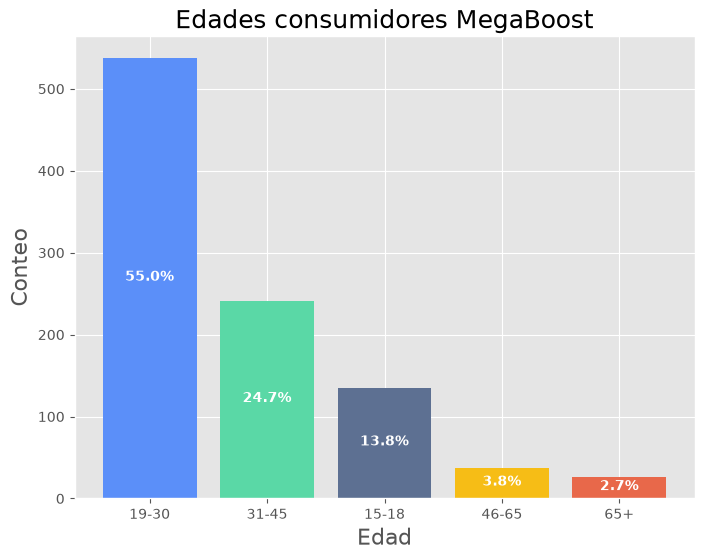

In [46]:
cats_edad = df_copy.loc[df_copy["marcas_que_consume"] == "MegaBoost", "edad"].value_counts().index.astype(str).to_list()
count_edad = df_copy.loc[df_copy["marcas_que_consume"] == "MegaBoost", "edad"].value_counts().to_list()
total = np.array(count_edad).sum()

fig, ax = plt.subplots(figsize=(8,6))
#Modificar titulo
ax.set_title("Edades consumidores MegaBoost", fontsize=18)
#Modificar labels X e Y
ax.set_xlabel("Edad", fontsize=16)
ax.set_ylabel("Conteo", fontsize=16)

colores_edades = ["#5B8FF9", "#5AD8A6", "#5D7092", "#F6BD16", "#E8684A"]
etiquetas_pct = [f"{(valor / total) * 100:.1f}%" for valor in count_edad]

barras = ax.bar(cats_edad, count_edad, color=colores_edades)

ax.bar_label(barras, labels=etiquetas_pct, label_type="center", color="white", padding=1, fontsize=10, fontweight="bold")

plt.savefig(r'.\plots\rango_edades.png', dpi=300);
plt.show()


### 5.2. Canales de marketing más efectivos

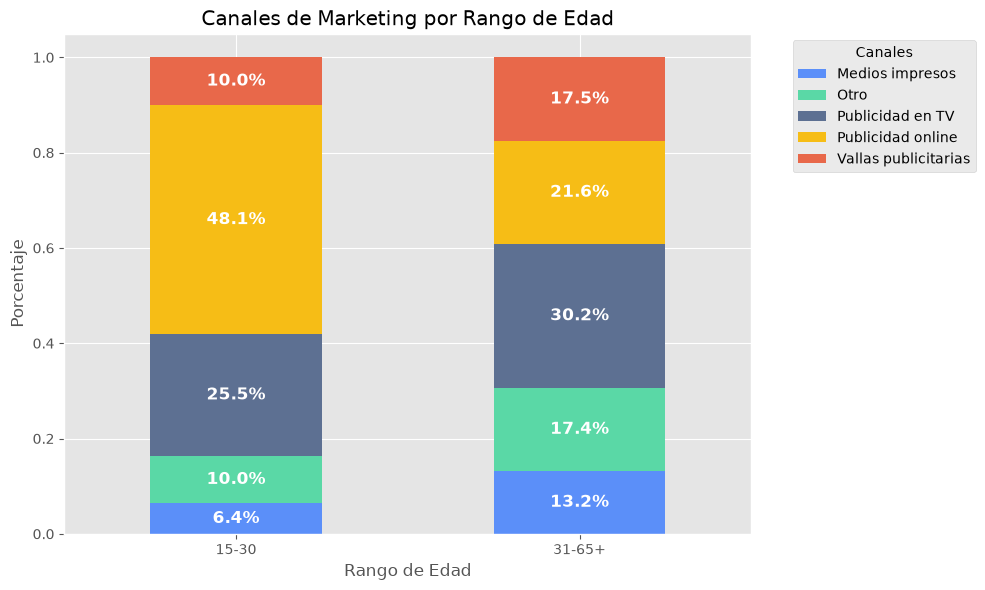

In [43]:
#conteo = df_copy.groupby(["edad","canales_marketing"]).count()
mapeo = {
    "15-18": "15-30",
    "19-30": "15-30",
    "31-45": "31-65+",
    "46-65": "31-65+",
    "65+": "31-65+"
}

conteo = df_copy.groupby(df_copy['edad'].replace(mapeo))['canales_marketing'].value_counts(normalize=True)

# Preparar la estructura desapilada
df_plot = df_copy.groupby(df_copy['edad'].replace(mapeo))['canales_marketing'].value_counts(normalize=True).unstack()

#Graficar
fig, ax = plt.subplots(figsize=(10, 6))
df_plot.plot(kind='bar', stacked=True, ax=ax, color=colores_edades)

# 3. Agrega los porcentajes adentro de cada segmento
for c in ax.containers:
    # Solo muestra la etiqueta si el valor es mayor a 0 (para no encimar ceros)
    labels = [f'{v * 100:.1f}%' for v in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=12, color='white', weight='bold')

# Formato final
plt.title('Canales de Marketing por Rango de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.legend(title='Canales', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig(r'.\plots\canales_marketing.png', dpi=300);
plt.show()

### 5.3. Líderes del mercado

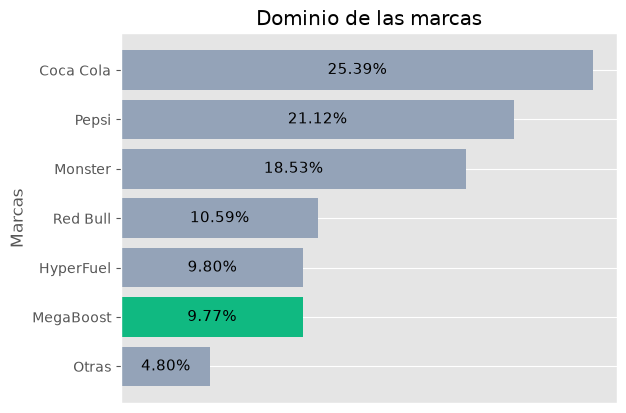

In [44]:
conteo_marcas = df_copy["marcas_que_consume"].value_counts()
pct  = df_copy["marcas_que_consume"].value_counts(normalize=True).map("{:.2%}".format).to_list()

colores = [
    '#10B981' if marca == 'MegaBoost' else '#94A3B8'
    for marca in conteo_marcas.index
]

fig, ax = plt.subplots()



barritas = ax.barh(conteo_marcas.index, conteo_marcas.values, color=colores)

ax.set_title("Dominio de las marcas")
ax.set_ylabel("Marcas")

ax.invert_yaxis()
ax.bar_label(barritas, pct, label_type="center", fontsize=11)
ax.get_xaxis().set_visible(False)
#plt.savefig(r'.\plots\dominio_marcas.png', dpi=300);
plt.show()

### 5.4. Posicionamientos de la marca

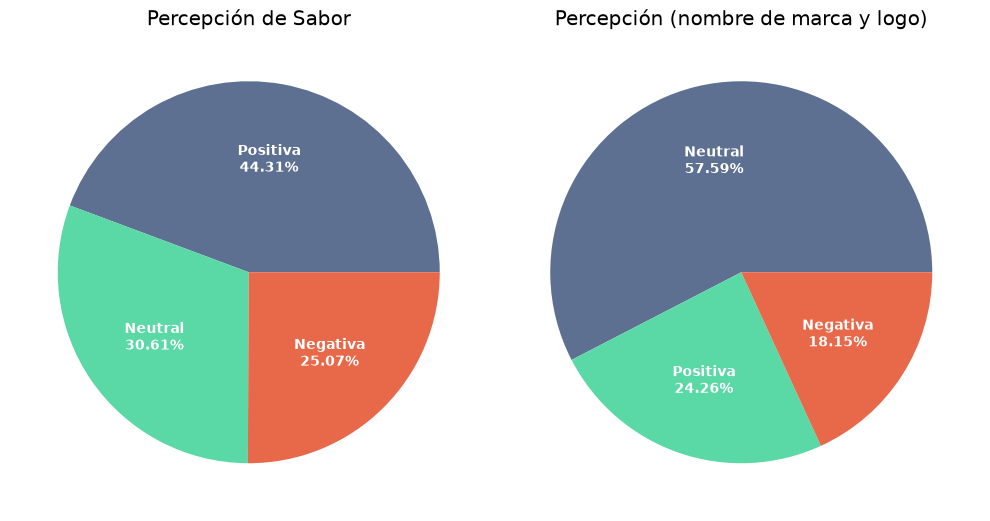

In [45]:
#preparación plot1
mapeo_sabor = {
    "1": 'Negativa',
    "2": 'Negativa',
    "3": 'Neutral',
    "4": 'Positiva',
    "5": 'Positiva'
}
filtro = (df_copy["conocia_marca"] == "Sí") & (df_copy["habia_probado"] == "Sí")
resultado = df_copy[filtro]["experiencia_sabor"].replace(mapeo_sabor).value_counts(normalize=True)
etiquetas_formateadas_sabor = [f'{label}\n{val:.2f}%' for label, val in zip(resultado.index, resultado.values*100)]



#Preparación plot 2
percepcion = df_copy[(df_copy["conocia_marca"] == "Sí")]["percepcion_marca"].value_counts(normalize=True)
data_perc = [x for x in percepcion.values]
etiquetas_formateadas_marca= [f'{label}\n{val:.2f}%' for label,
                         val in zip(percepcion.index, percepcion.values*100)]

#PLOTEO Graficos 1 y 2
fig, axs = plt.subplots(1,2, figsize=(10,6))

#Grafico 2
axs[0].set_title("Percepción de Sabor")
pie1 = axs[0].pie(resultado, colors=["#5D7092", "#5AD8A6", "#E8684A"])
axs[0].pie_label(pie1, etiquetas_formateadas_sabor, textprops={'color': 'white', 'weight': 'bold', 'ha': 'center'})

#Grafico 2
axs[1].set_title("Percepción (nombre de marca y logo)")
pie2 = axs[1].pie(data_perc, colors=["#5D7092", "#5AD8A6", "#E8684A"])
axs[1].pie_label(pie2,etiquetas_formateadas_marca, textprops={'color': 'white', 'weight': 'bold', 'ha': 'center'})

plt.tight_layout()
#plt.savefig(r'.\plots\posicionamiento_marca', dpi=300);
plt.show()


## 6. Reporte Final y Recomendaciones

### 6.1. Reporte Final

Tras el análisis realizado observamos que:

* **Perfil Demográfico:** El género que más consume nuestra bebida son los hombres, y el grupo de edad con más consumidores de nuestro producto es el de **19 a 30 años** (55%), seguido por el rango de **31 a 45 años** (24.7%).

<img src=".\plots\rango_edades.png" width="700"> 

* **Competencia y Posicionamiento:** Los líderes actuales del mercado son Coca-Cola (25.38%), Pepsi (21.12%) y Monster (18.54%), acumulando cerca del 65% de participación. **MegaBoost** se encuentra en el **5º lugar con un 9.80%** de cuota de mercado.

<img src=".\plots\dominio_marcas.png" width="700"> 

* **Percepción de Marca:** 
  * Nuestra marca y logo no generan suficiente recordación en los compradores y los consumidores no están del todo satisfechos con el sabor de la bebida.
  * En 8 de las 10 ciudades italianas con presencia, la gente **NO** conoce nuestra marca.
  * Los consumidores prefieren otras marcas debido a su reputación, disponibilidad y sabor.

<img src=".\plots\posicionamiento_marca.png" width="700"> 

* **Canales de Marketing Efectivos:** La publicidad online y la televisión son los medios más efectivos. La **publicidad online** predomina ampliamente en el rango de **15–30 años** (48.1%), mientras que la **TV** cobra mayor relevancia en el grupo de **31 a 65+ años** (30.2%).

<img src=".\plots\canales_marketing.png" width="700"> 

* **Preferencias del Consumidor:**
  * **Ingredientes:** Los preferidos son la cafeína y las vitaminas.
  * **Empaque:** Predilección por las latas portables y compactas.
  * **Ocasiones de consumo:** Las situaciones más comunes son al hacer deporte o al trabajar/estudiar hasta tarde.
  * **Puntos de venta:** La mayor parte de las compras se realizan en supermercados.
  * **Factores de decisión:** Influyen principalmente la reputación de la marca, el sabor y la disponibilidad en góndola.
  * **Sugerencias de usuarios:** Reducir el contenido de azúcar y agregar más ingredientes naturales.

### 6.2. Recomendaciones

Con base en los hallazgos anteriores, se sugieren las siguientes estrategias:

1. Mantener estrategias de publicidad dirigidas a hombres entre los 19 y 30 años, especialmente en la modalidad online y publicidad en medios de televisión dirigidas a los rangos de 31 a 65 o más años.
2. Reforzar las estrategias de publicidad dirigidas a  dos segmentos: (1) los géneros mujeres y no binario y (2) en las ciudades de Palermo, Florencia, Venecia, Pisa, Turín, Génova, Verona, Siena
3. Modificar la fórmula para alinear el sabor con las preferencias de los consumidores, reducir el azúcar y añadir más ingredientes naturales como cafeína y vitaminas.
4. Fortalecer la cadena de distribución para garantizar que nuestra bebida esté disponible en las ciudades de interés y de forma prioritaria en los supermercados.
6. Mantener la comercialización en latas portables y compactas, orientando el mensaje de las campañas hacia los dos escenarios de consumo más frecuentes: hacer deporte y energia para rendir en el trabajo/estudio.